# 02 — Three-layer encoding framework

Full implementation of Zhang et al. (MEC 2026) on KV279 mvt.1.

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import partitura as pt, warnings
warnings.filterwarnings('ignore')
from layers import (extract_pedal_events, build_score_to_perf_map, build_beat_grid,
                    layer2_descriptors, layer3_labels, beat_unit_from_timesig_str)

DATASET  = '/Volumes/Extreme SSD/batik_plays_mozart'
MOVEMENT = 'kv279_1'
TIMESIG  = '4/4'

In [2]:
perf, alignment, score = pt.load_match(
    f'{DATASET}/match/{MOVEMENT}.match', create_score=True)
sna = score.note_array(); pna = perf.note_array(); pp = perf.performedparts[0]
cc64  = sorted([c for c in pp.controls if c['number']==64], key=lambda c: c['time'])
t_raw = np.array([c['time']  for c in cc64])
v_raw = np.array([c['value'] for c in cc64]) / 127.0
bu = beat_unit_from_timesig_str(TIMESIG)
q2t = build_score_to_perf_map(sna, pna, alignment)
beat_qs, beat_ts = build_beat_grid(sna, q2t, beat_unit=bu)
print(f'{MOVEMENT}: {len(sna)} score notes, {len(cc64)} CC64 messages')

kv279_1: 2803 score notes, 7620 CC64 messages


## Layer I — Pedal event segmentation

Events: 240  |  mean: 0.51s  median: 0.44s


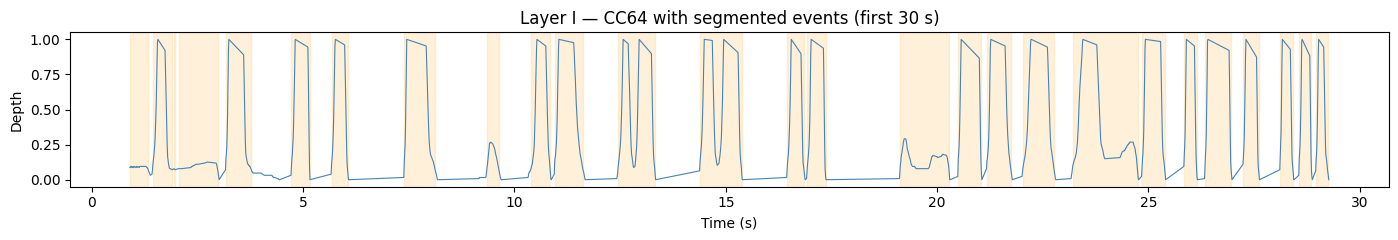

In [3]:
events = extract_pedal_events(pp.controls, threshold=10)
durs = [e.offset_sec - e.onset_sec for e in events]
print(f'Events: {len(events)}  |  mean: {np.mean(durs):.2f}s  median: {np.median(durs):.2f}s')

fig, ax = plt.subplots(figsize=(14, 2.5))
mask = t_raw < 30
ax.plot(t_raw[mask], v_raw[mask], lw=0.8, color='steelblue')
for ev in events:
    if ev.onset_sec < 30:
        ax.axvspan(ev.onset_sec, min(ev.offset_sec, 30), alpha=0.15, color='orange')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Depth')
ax.set_title('Layer I — CC64 with segmented events (first 30 s)')
plt.tight_layout(); plt.show()

## Layer II — Score-aligned descriptors

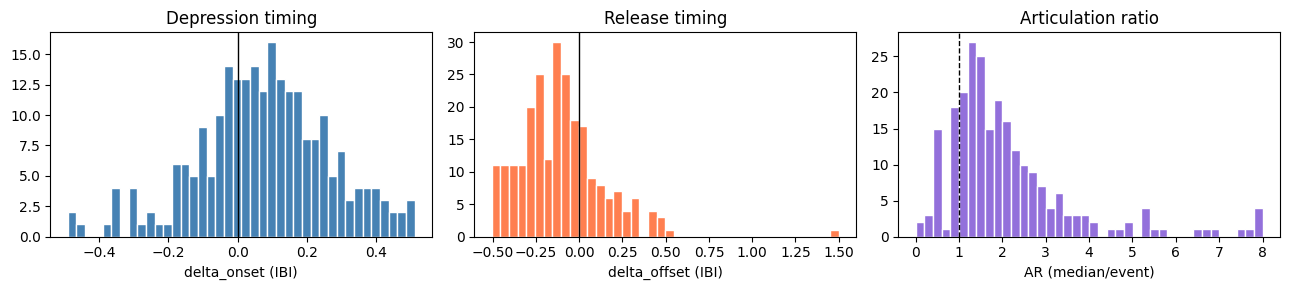

delta_onset mean=0.074  delta_offset mean=-0.103
AR median=1.74  (>1 means notes held past natural IOI)


In [4]:
layer2_descriptors(events, beat_qs, beat_ts, sna, pna, alignment, q2t)
d_on  = np.array([e.delta_onset  for e in events if e.delta_onset  is not None])
d_off = np.array([e.delta_offset for e in events if e.delta_offset is not None])
ars   = [np.median(e.ar_notes)   for e in events if e.ar_notes]

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
axes[0].hist(np.clip(d_on,  -1.5, 1.5), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='k', lw=1); axes[0].set_xlabel('delta_onset (IBI)'); axes[0].set_title('Depression timing')
axes[1].hist(np.clip(d_off, -1.5, 1.5), bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', lw=1); axes[1].set_xlabel('delta_offset (IBI)'); axes[1].set_title('Release timing')
axes[2].hist(np.clip(ars, 0, 8), bins=40, color='mediumpurple', edgecolor='white')
axes[2].axvline(1, color='k', lw=1, ls='--'); axes[2].set_xlabel('AR (median/event)'); axes[2].set_title('Articulation ratio')
plt.tight_layout(); plt.show()
print(f'delta_onset mean={d_on.mean():.3f}  delta_offset mean={d_off.mean():.3f}')
print(f'AR median={np.median(ars):.2f}  (>1 means notes held past natural IOI)')

## Layer III — Semantic labels

In [5]:
layer3_labels(events)
from collections import Counter
label_counts = Counter(lbl for e in events for lbl in e.labels)
print('Label distribution:')
for lbl, cnt in label_counts.most_common():
    print(f'  {lbl:20s} {cnt:4d}  ({100*cnt/len(events):.1f}%)')

Label distribution:
  rhythmic              126  (52.5%)
  sustaining             52  (21.7%)
  over-legato            44  (18.3%)
  half-pedal             41  (17.1%)
  anticipatory           30  (12.5%)
  other                  16  (6.7%)
  touch                   2  (0.8%)


## Figure 3 — Score-aligned four-panel view

Piano roll (score context) + raw depth (I) + timing deltas (II) + semantic label bands (III).

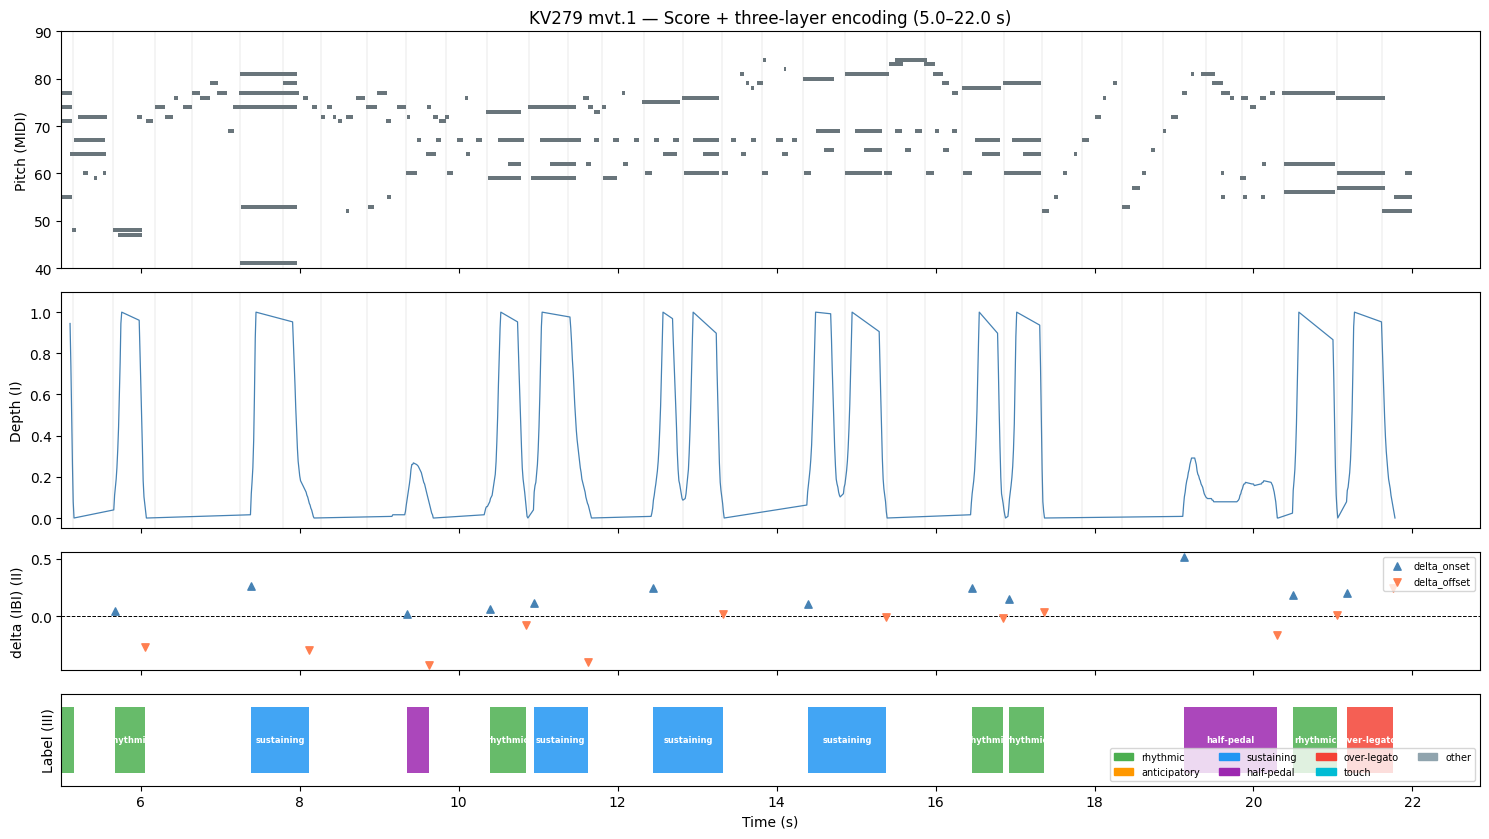

In [6]:
T_START, T_END = 5.0, 22.0

LABEL_COLORS = {
    'rhythmic':     '#4CAF50',
    'anticipatory': '#FF9800',
    'sustaining':   '#2196F3',
    'half-pedal':   '#9C27B0',
    'over-legato':  '#F44336',
    'touch':        '#00BCD4',
    'other':        '#90A4AE',
}

# Build performed note lookup for piano roll
p_id2on  = {n['id']: float(n['onset_sec'])                            for n in pna}
p_id2off = {n['id']: float(n['onset_sec']) + float(n['duration_sec']) for n in pna}
p_id2pit = {n['id']: int(n['pitch'])                                  for n in pna}

fig, axes = plt.subplots(4, 1, figsize=(15, 8.5), sharex=True,
                          gridspec_kw={'height_ratios': [1.8, 1.8, 0.9, 0.7]})

# ── Panel 0: Piano roll ──────────────────────────────────────────────────────
ax = axes[0]
for pid, t_on in p_id2on.items():
    t_off = p_id2off[pid]; pit = p_id2pit[pid]
    if t_off < T_START or t_on > T_END: continue
    x0 = max(t_on, T_START); x1 = min(t_off, T_END)
    ax.barh(pit, x1 - x0, left=x0, height=0.85,
            color='#37474F', alpha=0.75)
ax.set_ylabel('Pitch (MIDI)')
ax.set_ylim(40, 90)
ax.set_title(f'KV279 mvt.1 — Score + three-layer encoding ({T_START}–{T_END} s)')

# ── Panel 1: Layer I depth ───────────────────────────────────────────────────
ax = axes[1]
mask = (t_raw >= T_START) & (t_raw <= T_END)
ax.plot(t_raw[mask], v_raw[mask], lw=0.9, color='steelblue')
ax.set_ylabel('Depth (I)'); ax.set_ylim(-0.05, 1.1)

# beat grid on panels 0 and 1
for bt in beat_ts[(beat_ts >= T_START) & (beat_ts <= T_END)]:
    axes[0].axvline(bt, color='grey', lw=0.3, alpha=0.4)
    axes[1].axvline(bt, color='grey', lw=0.3, alpha=0.4)

# ── Panel 2: Layer II deltas ─────────────────────────────────────────────────
ax = axes[2]
seen = set()
for ev in events:
    if T_START <= ev.onset_sec <= T_END and ev.delta_onset is not None:
        kw_on  = dict(label='delta_onset')  if 'on'  not in seen else {}
        kw_off = dict(label='delta_offset') if 'off' not in seen else {}
        ax.scatter(ev.onset_sec,  ev.delta_onset,  marker='^', s=28,
                   color='steelblue', zorder=3, **kw_on)
        ax.scatter(ev.offset_sec, ev.delta_offset, marker='v', s=28,
                   color='coral',     zorder=3, **kw_off)
        seen.update(['on', 'off'])
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_ylabel('delta (IBI) (II)')
ax.legend(fontsize=7, loc='upper right')

# ── Panel 3: Layer III labels ─────────────────────────────────────────────────
ax = axes[3]
ax.set_ylim(0, 1); ax.set_yticks([])
for ev in events:
    if ev.offset_sec < T_START or ev.onset_sec > T_END: continue
    x0 = max(ev.onset_sec, T_START); x1 = min(ev.offset_sec, T_END)
    primary = ev.labels[0] if ev.labels else 'other'
    ax.barh(0.5, x1 - x0, left=x0, height=0.72,
            color=LABEL_COLORS.get(primary, '#90A4AE'), alpha=0.85)
    if x1 - x0 > 0.35:
        ax.text((x0+x1)/2, 0.5, primary, ha='center', va='center',
                fontsize=6, color='white', fontweight='bold')
ax.set_ylabel('Label (III)'); ax.set_xlabel('Time (s)')

patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=7, ncol=4)

plt.tight_layout(); plt.show()